# The Josephson effect - et VitBer prosjekt innen teknisk fysikk

# Oppgave 1

## a)

Analytisk løsning av initialverdiproblemet: 

$$
\frac{d^2 y}{dx^2} = -4 \sin(2x), \quad y(0) = 0, \quad y'(0) = 2
$$

$$
\int\frac{d^2 y}{dx^2} = \int -4\sin(2x) dx
$$
Vi bruker standardintegralet: 

$$
\int\sin(ax)dx = -\frac{1}{a}\cos(ax)
$$
$a = 2$
$$
y' = \int-4\sin(2x)dx = \frac{4}{2}\cos(2x) + C_1 = 2\cos(2x)+ C_1 
$$
Så bruker vi initialbetingelsen: $y'(0)= 2$ 
$$
2\cos(0) + C_1 = 2 
$$
$$
2 + C_1 = 2 \rightarrow C_1 = 0
$$
Den første deriverte blir da:
$$
y'=2\cos(2x)dx
$$

Vi integrerer igjen:

$$
\int y'= \int 2\cos(2x)dx 
$$
Så kan vi bruke standardintegralet: 
$$
\int\cos(ax)dx = \frac{1}{a}\sin(ax)
$$
for $a = 2$
$$
y = \frac{2}{2}\sin(2x) +C_2 = \sin(2x)+ C_2
$$
Deretter bruker vi den andre initialbetingelsen: y(0)= 0

$$
\sin(0)+ C_2 = 0 \rightarrow C_2 = 0
$$

Da blir det endelige svaret: 
$$
y = \sin(2x)
$$

## b)

Først definerer vi vektoren  $y(x)$: 

$$
\mathbf{y}(x) = 
\begin{bmatrix}
y(x) \\
y'(x)
\end{bmatrix}

$$


Så definierer vi de nye variablene: 
$$
y_1 = y , 

y_2 = y'
$$



$$
\frac{d}{dx}
\begin{bmatrix}
y_1 \\
y_2
\end{bmatrix}
=
\begin{bmatrix}
y_2 \\
-4 \sin(2x)
\end{bmatrix}, 
$$

Initialbetingelsene: 

$$
\mathbf{y}(0) = 
\begin{bmatrix}
0\\
2
\end{bmatrix}
$$

## c)

In [ ]:
# Importerer nødvendige biblioteker
import numpy as np
import matplotlib.pyplot as plt
import time
import scipy
from scipy.integrate import solve_bvp

In [ ]:
# Lager funksjonen beskrevet i oppgaven

def RungeKutta_32(x_init, x_end, y_init, f, alpha, h_0, tol):
    n = 0                           # Teller antall steg som aksepteres
    n_total = 0                     # Teller antall steg som testes
    h_n = h_0                       # Steglengde ved steg n
    x_n = x_init                    # x-verdi ved steg n
    y_n = y_init                    # y-vektor ved steg n
    
    x_array = [x_n]                 # Liste med x-verdier for hvert steg
    y_matrix = [y_n]                # 2D-liste med y-vektor for hvert steg 
    step_array = []                 # Liste til steglengde for hvert steg


    k_1 = f(x_init, y_init)

    while (x_end - x_n) > 0:
        h_n = min(h_n, x_end - x_n)
        k_2 = f(x_n + (1/2)*h_n, y_n + (1/2)*h_n*k_1)
        k_3 = f(x_n + (3/4)*h_n, y_n + (3/4)*h_n*k_2)

        y_next = y_n + (1/9)*h_n*(2*k_1 + 3*k_2 + 4*k_3)                # Midlertidig oppdatering av y
        x_next = x_n + h_n                                              # Midlertidig oppdatering av x

        k_4 = f(x_next, y_next)
        z_next = y_n + (1/24)*h_n*(7*k_1 + 6*k_2 + 8*k_3 + 3*k_4)       # Beregner alternativ y for sammenligning

        est = np.linalg.norm(y_next - z_next)
        if est < tol:                                                   # Sjekker om skrittet aksepteres
            n += 1                                                      # Oppdaterer antall skritt
            k_1 = k_4                                                   # Oppdaterer k_1
            
            x_array.append(x_next)                                      # Legger til x-verdi i listen siden skrittet aksepteres
            y_matrix.append(y_next)                                     # Legger til y-vektor i listen siden skrittet aksepteres
            step_array.append(h_n)                                      # Legger til steglengde i listen siden skrittet aksepteres
            
            x_n = x_next                                                # Oppdaterer x-verdi siden skrittet aksepteres
            y_n = y_next                                                # Oppdaterer y-vektor siden skrittet aksepteres

        h_new = alpha*h_n*(tol/est)**(1/3)                              # Beregner ny steglengde  
        h_n = h_new                                                     # Oppdaterer steglengden

        n_total += 1                                                    # Oppdaterer antall testede skritt


    return np.array(x_array), np.array(y_matrix), np.array(step_array), n, n_total

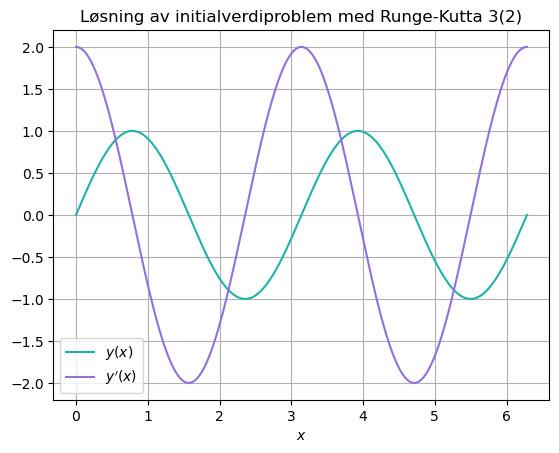

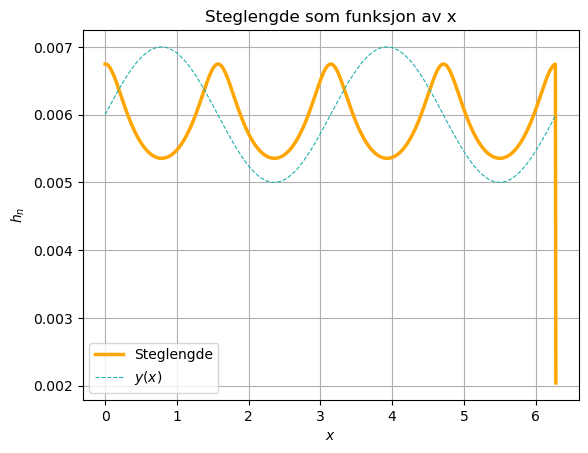

In [ ]:
# Beregner y(x) og y'(x)

x_init, x_end = 0, 2*np.pi
alpha = 0.8
tol = 10**(-7)
h_0 = 0.01

y_init = np.array([0, 2])

def f_array(x, y_array):                                                   # Definerer f som returnerer vektor
    f = -4*np.sin(2*x)                                                    
    f_array = np.array([y_array[1], f])
    return f_array


x_values, y_matrix, step_array, n, n_total = RungeKutta_32(x_init, x_end, y_init, f_array, alpha, h_0, tol) 
y_values = y_matrix[:, 0]                                                  # Henter y-verdier
dy_values = y_matrix[:, 1]                                                 # Henter dy-verdier


# Plotter y(x) og y'(x)
plt.plot(x_values, y_values, label = '$y(x)$', color = 'lightseagreen')
plt.plot(x_values, dy_values, label = "$y'(x)$", color = 'mediumpurple')
plt.title("Løsning av initialverdiproblem med Runge-Kutta 3(2)")
plt.xlabel('$x$')
plt.grid()
plt.legend()
plt.show()

# Plotter steglengden som funksjon av x
plt.plot(x_values[:-1], step_array, label = 'Steglengde', color = 'orange', linewidth = 2.5)
plt.plot(x_values, 0.001*y_values+0.006, label = '$y(x)$', color = 'lightseagreen', linewidth = 0.8, linestyle = '--')
plt.title('Steglengde som funksjon av x')
plt.xlabel('$x$')
plt.ylabel('$h_n$')
plt.legend()
plt.grid()
plt.show() 

Fra plottene over ser vi at steglengden har maksimumspunkter der y(x) har vendepunkter. 
Der y(x) har vendepunkter endrer stigningstallet seg minst, og funksjonen fremstår lokalt lineær. Det er dermed naturlig å tillate seg å ha lenger steglengde rundt disse x-verdiene.

Vi ser også at steglengden har minimumspunkter der y(x) har ekstremalpunkter. 
I ekstremalpunktene til y(x) endrer stigningstallet seg mest. Da vil RK-metoden ta mindre steg rundt disse x-verdiene for å minimere feilen i approksimasjonen.

På slutten av x-intervallet ser vi at steglengden blir drastisk kortere. Dette er fordi steget fra nest siste x-verdi til siste x-verdi vil være et reststeg, som dermed ikke beregnes av steglengde-algoritmen. Dette ressteget dekker avstanden fra nest siste x-verdi til randpunktet for funksjonen, og kan dermed være svært mye mindre enn de tidligere stegene. 

## d)

In [ ]:
def analyticalSolution(x):                             # Funksjon for å beregne analytisk løsning
    y = np.sin(2*x)
    return y


def maxActualError(x_init, x_end, y_init, f_array, alpha, h_0, tol):
    x_values, y_matrix, step_array, n, n_total = RungeKutta_32(x_init, x_end, y_init, f_array, alpha, h_0, tol) 
    y_values_RK = y_matrix[:, 0] 

    y_values_analytical = analyticalSolution(x_values) # Liste med analytisk løsning 

    error = abs(y_values_analytical - y_values_RK)     # Beregner absoluttfeil i alle punkter
    maxError = max(error)                              # Finner den største feilen

    return maxError

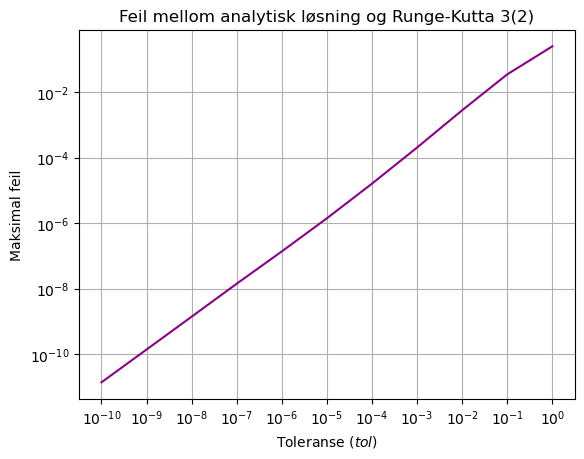

In [ ]:
tol_array = np.array([10**i for i in range(-10, 1)])   # Array med ulike toleranser
maxError_array = []                                    # Liste til maksimalfeil for ulike toleranser
for tol in tol_array:       
    maxError_array.append(maxActualError(x_init, x_end, y_init, f_array, alpha, h_0, tol))  # Henter maksimal feil for hver toleranse


# Plotter maksimalfeil som funksjon av toleransen
plt.plot(tol_array, maxError_array, color = 'darkmagenta')
plt.title('Feil mellom analytisk løsning og Runge-Kutta 3(2)')

plt.xlabel('Toleranse ($tol$)')
plt.xscale('log')
plt.xticks(tol_array)
plt.yscale('log')
plt.ylabel('Maksimal feil')

plt.grid()
plt.show()

Plottet over viser hvordan den maksimale feilen mellom analytisk og numerisk løsning endres som funksjon av toleransen. 
Resultatet over stemmer godt overens med intuisjonen da større toleranse for feil naturligvis vil medføre større feil i den numeriske metoden.

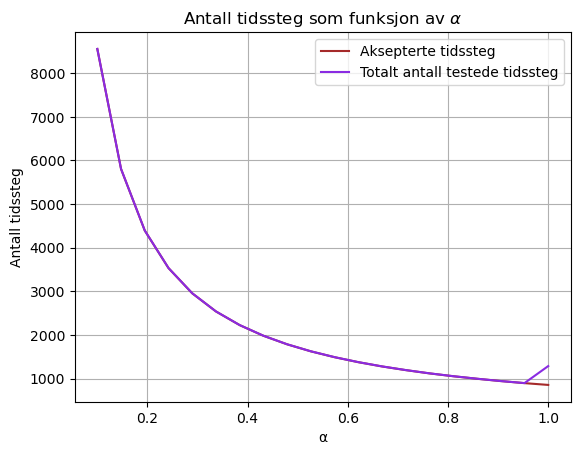

In [ ]:
alpha_array = np.linspace(0.1, 1.0, 20)             # Array med ulike alfa-verdier
tolerance = 10**(-7)

n_array = []                                        # Liste for antall aksepterte tidssteg
n_total_array = []                                  # Liste for totalt antall testede tidssteg

for alphaValue in alpha_array:                      # Itererer gjennom alle alfaverdier
    x_values, y_matrix, step_array, n, n_total = RungeKutta_32(x_init, x_end, y_init, f_array, alphaValue, h_0, tolerance)
    n_array.append(n)                               # Lagrer antall aksepterte tidssteg for gitt alfa           
    n_total_array.append(n_total)                   # Lagrer totalt antall testede tidssteg for gitt alfa


# Plotter antall tidssteg som funksjon av alfa
plt.plot(alpha_array, n_array, label = 'Aksepterte tidssteg', color = 'brown')
plt.plot(alpha_array, n_total_array, label = 'Totalt antall testede tidssteg', color = 'blueviolet')
plt.title('Antall tidssteg som funksjon av $α$')
plt.xlabel('α')
plt.ylabel('Antall tidssteg')
plt.legend()
plt.grid()
plt.show()

$α$ er en såkalt pessimistfaktor som er med på å balansere nøyaktigheten til Runge-Kutta-metoden mot effektiviteten til metoden. $α$-verdien avgjør hvor drastisk steglengden endrer seg mellom iterasjoner. 

Av plottet over ser vi at lave verdier for $α$ gir svært mange tidssteg. For lave $α$-verdier er man pessimistisk og $h_n$ holder seg svært lav, noe som resulterer i mange tidssteg. 

Plottet over viser at det å velge høyere $α$-verdier raskt vil kreve et mindre antall tidssteg i Runge-Kutta-metoden. 
Ved høye $α$-verdier er man optimistisk, og $h_n$ endrer seg mer for hver iterasjon. Dette resulterer i færre tidssteg, men ved for høye $α$-verdier vil det også føre til at flere tidssteg blir avvist. I plottet over ser vi at antall testede tidssteg plutselig stiger når $α$ nærmer seg 1.0. 
Dette er fordi tidsstegene blir så store at flere blir avvist og dermed må beregnes på nytt. 

## e)

In [ ]:
def rootFinder(g, z0, z1, tol, max_iter = 100): 
    b_values = [z0, z1]                                         # Lager liste med b-verdier

    for i in range(max_iter):                                   # Sørger for øvre grense for antall iterasjoner

        g_z0, g_z1 = g(z0), g(z1)                               # Definerer funksjonsverdiene
        
        if abs(g_z1 - g_z0) < tol:                              # Unngår divisjon med null            
            print("Små forskjeller i funksjonsverdi, kan gi mulig feil")
            break 

        z2 = z1 - g_z1*(z1 - z0)/(g_z1 - g_z0)                  # Beregner ny b-verdi med sekantmetoden
        b_values.append(z2)                                     # Lagrer ny b-verdi

        if abs(z2 - z1) < tol:                                  # Sjekker konvergens
            return z2, np.array(b_values)                       # Returnerer b-verdien dersom den konvergerer
 
        z0, z1 = z1, z2                                         # Oppdaterer gjettene
    raise ValueError("")

In [ ]:
def g(z): 
    return z + np.sin(z) + np.cos(z)                           # Definerer funksjonen g(z) = z + sin(z) + cos(z)

# Tester rootFinder
z0 = -1
z1 = 0
tol = 1e-6

root, root_array = rootFinder(g, z0, z1, tol)
print(f"Rot funnet: {root}")
print(f"Funksjonsverdien til roten: {g(root)}")                # Bekrefter at riktig rot er funnet

Rot funnet: -0.456624704567631
Funksjonsverdien til roten: -3.3306690738754696e-16


Ovenfor ser vi en funkjson som benytter sekantmetoden for å finne roten av funkjsonen $g$. Deretter verifiserers løsningen ved å sette inn roten i $g$. Røttene til en funkjson kalles også nullpunkter, da de er punktene hvor $g(z) = 0$. Siden dette er en numerisk metode vil vi få en approksimert rot, og g(root) vil ikke være eksakt 0, men en verdi som er veldig nærme 0. Som vist over er rotverdien nær null, som bekrefter at løsningen er korrekt.

## f)

In [ ]:
# Funksjon for å løse randverdiproblem med skytemetoden

def solveBVproblem(x_init, x_end, f, z0, z1, alpha, h_0, tol):    
    xb_values = []                                                # Liste for å lagre alle testede løsninger
    yb_values = []                                                # Liste for å lagre alle testede løsninger

    def g(b):                                                     # Definerer funksjonen for siste grensebetingelse, gitt b
        y_init = np.array([0, b])                           
        x_values, y_matrix, step_array, n, n_total = RungeKutta_32(x_init, x_end, y_init, f, alpha, h_0, tol) # Løser IVP for gitt b
        y_end = y_matrix[-1, 0]                                   # Henter siste y-verdi    

        return y_end


    b, b_values = rootFinder(g, z0, z1, tol, max_iter=100)        # Henter b som gir oppfylt grensebetingelse og liste med testede b'er

    for value in b_values:                                        # Itererer gjennom alle testede b-verdier
        y_init = np.array([0, value])
        x_values, y_matrix, step_array, n, n_total = RungeKutta_32(x_init, x_end, y_init, f, alpha, h_0, tol) # Løser IVP for riktig b   
        xb_values.append(x_values)                                # Henter x-verdier for gitt b
        yb_values.append(y_matrix[:, 0])                          # Henter y-verdier for gitt b

    return xb_values, yb_values, b_values                         # Returnerer 2D-lister for x- og y-verdier for alle b, og liste over b'er

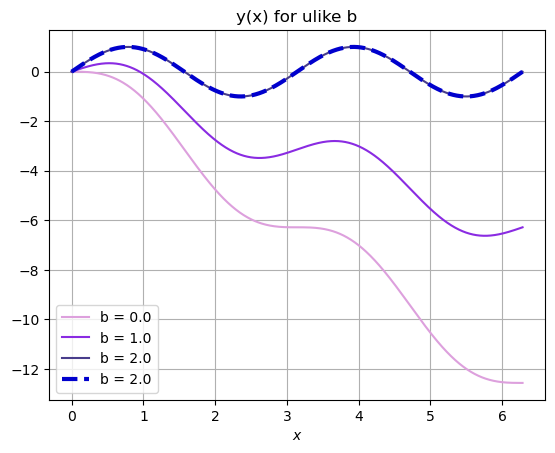

In [ ]:
# Løser randverdiproblem

alpha = 0.8
h_0 = 0.01
tol = 10**(-7)

x_init, x_end = 0, 2*np.pi
z0, z1 = 0, 1                                                              # Initielle gjett z0 og z1

def f_array(x, y_array):                                                   # Definerer f som returnerer vektor
    f = -4*np.sin(2*x)                                                    
    f_array = np.array([y_array[1], f])
    return f_array


xb_values, yb_values, b_values = solveBVproblem(x_init, x_end, f_array, z0, z1, alpha, h_0, tol) # Løser randverdiproblem med skytemetoden

iteration_num = len(yb_values)                                             # Antall testede b-verdier
colors = ["plum", "blueviolet", "darkslateblue", "royalblue"]

for i in range(iteration_num - 1):                                         # Itererer gjennom alle b-verdier unntatt den endelige                                          
    plt.plot(xb_values[i], yb_values[i], color = colors[i], label = f'b = {round(b_values[i], 3)}')


# Plotter den riktige løsningen av randverdiproblemet
plt.plot(xb_values[-1], yb_values[-1], label = f'b = {round(b_values[-1], 3)}', color = "mediumblue", linewidth = 3, linestyle = '--') 
plt.xlabel("$x$")
plt.title("y(x) for ulike b")
plt.grid()
plt.legend()
plt.show()

I plottet over ser vi løsningen $y(x)$ av randverdiproblemet for hver iterasjon av sekant-metoden. 
Vi ser at hvert "skudd" med skytemetoden er nærmere enn det forrige, inntill løsningen konvergerer for $b = 2.0$. 

## g)

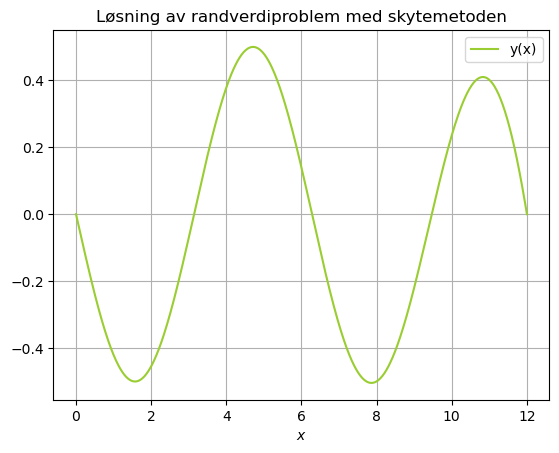

In [ ]:
def g_array(x, y_array):                                            # Definerer funksjon g som returnerer vektor
    g_array = np.array([y_array[1], y_array[0] + np.sin(x)])
    return g_array

alpha = 0.8
h_0 = 0.01
tol = 10**(-7)

x_init, x_end = 0, 12                                               # Randverdier for x
z0, z1 = 0, 1                                                       # Initielle gjett for z0 og z1

start_shootingMethod = time.time()                                  # Variabel for startverdi for kjøretid

xb_values, yb_values, b_values = solveBVproblem(x_init, x_end, g_array, z0, z1, alpha, h_0, tol) # Finner løsning av randverdiproblemet

end_shootingMethod = time.time()                                    # Variabel for sluttverdi for kjøretid


# Plotter y(x)
plt.plot(xb_values[-1], yb_values[-1], label = "y(x)", color = "yellowgreen")
plt.title("Løsning av randverdiproblem med skytemetoden")
plt.xlabel("$x$")
plt.grid()
plt.legend()
plt.show()

Over ser vi løsningen $y(x)$ av randverdiproblemet $\frac{d^2 y}{dx^2} = y(x) + \sin(x)$, $y(0) = y(12) = 0$,  løst med skytemetoden.

## h)

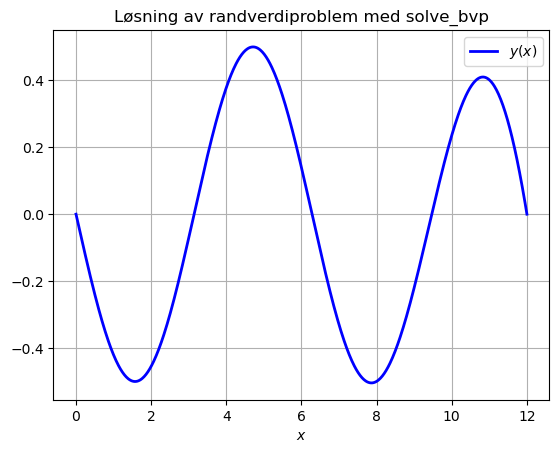

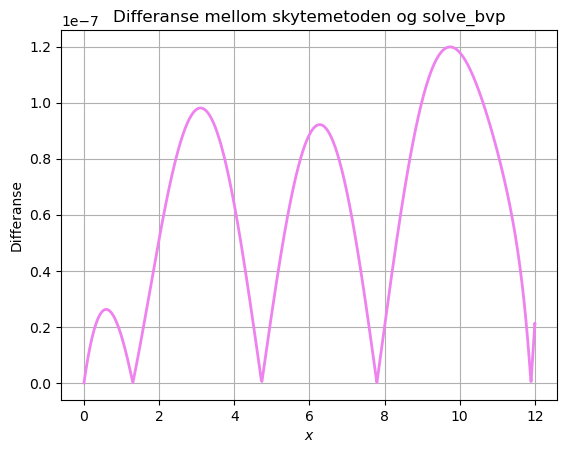

In [ ]:
# Løser randverdiproblem med solve_bvp

def bc(ya, yb):                                 # Funksjon for randbetingelser
    return np.array([ya[0], yb[0]])

y_guess = np.zeros((2, xb_values[-1].size))     # Argument til solve_bvp, 2D-array med dimensjoner antall 1. ordens ODE, x-verdier

start_solveBVP = time.time()                                # Variabel for startverdi for kjøretid
solution = solve_bvp(g_array, bc, xb_values[-1], y_guess)   # Henter løsning med solve_bvp
end_solveBVP = time.time()                                  # Variabel for sluttverdi for kjøretid

plt.plot(solution.x, solution.y[0], label=r"$y(x)$", color = "blue", linewidth = 2) # Plotter løsning med solve_bvp

plt.xlabel("$x$")
plt.title("Løsning av randverdiproblem med solve_bvp")
plt.legend()
plt.grid()
plt.show()

# Beregner feilen mellom skytemetoden og solve_bvp
difference = np.abs(np.array(solution.y[0]) - yb_values[-1])                        # Beregner differanse mellom løsning fra solve_bvp og skytemetoden

plt.plot(xb_values[-1], difference, color = "violet", linewidth = 2)                # Plotter feilen som funksjon av x                

plt.title("Differanse mellom skytemetoden og solve_bvp")
plt.xlabel(r"$x$")
plt.ylabel("Differanse")
plt.grid()
plt.show()


Plottene over viser henholdsvis løsningen $y(x)$ av $\frac{d^2 y}{dx^2} = y(x) + \sin(x)$, $y(0) = y(12) = 0$, løst med solve_bvp, og differansen mellom løsningen til skytemetoden og solve_bvp. 

Fra plottene over ser vi at feilen er størst for x-verdiene der $y(x)$ har vendepunkter. 
Med skytemetoden beregnes initialbetingelsen $y'(0) = b$ numerisk ved hjelp av sekantmetoden. En liten feil i beregningen av $b$ vil medføre en liten faseforskyvning i utregningen av $y(x)$. Denne faseforskyvningen vil gi utslag i beregningen av differansen mellom solve_bvp og skytemetoden.
Feilen vil gi mindre utslag i områder der stigningstallet er lavt, da en liten endring i x-retning ikke vil medføre noen stor endring i y-retning. 
I områder der kurven er svært bratt, som i vendepunktene, vil derimot en liten endring i x-retning medføre en stor endring i y-retning. 
En liten faseforskyvning i x-retning vil dermed gi størst utslag i disse områdene, slik plottene over viser. 

Vi kan også se en tendens til at feilen øker for høyere x-verdier. Dette kan forklares av forplantning av lokale feil i Runge-Kutta-metoden. 
Slik Runge-Kutta-metoden er bygd opp vil en liten feil i approksimasjonen bidra til nye feil i neste iterasjon. Dette kan føre til store akkumulerte feil, noe som gjerne trekkes fram som en av nedsidene ved å bruke denne numeriske metoden. 

In [ ]:
runningTime_shootingMethod = end_shootingMethod - start_shootingMethod
runningTime_solveBVP = end_solveBVP - start_solveBVP

print('Kjøretid for skytemetoden: ', runningTime_shootingMethod)
print('Kjøretid for solve_bvp: ', runningTime_solveBVP)
print(f'Solve_bvp går {round(runningTime_shootingMethod/runningTime_solveBVP, 2)} raskere enn skytemetoden.')

Kjøretid for skytemetoden:  0.785858154296875
Kjøretid for solve_bvp:  0.12701106071472168
Solve_bvp går 6.19 raskere enn skytemetoden.


Vi ser over at kjøretiden for solve_bvp er over svært mye kortere enn kjøretiden for skytemetoden slik den er implementert i denne oppgaven. 
For mer krevende beregninger enn de gjort i denne oppgaven kan dette være avgjørende, og det er tydelig at solve_bvp vil være en mer effektiv metode å bruke. 

# Oppgave 2

In [1]:
# Setter plot størrelse
plt.rcParams['figure.figsize'] = [10, 6]

NameError: name 'plt' is not defined

## a)

In [ ]:
def matrixToVector(M):
    # Initialiserer en null vektor dobbel så lang som antall elementer i matrisen(2*4)
    v = np.zeros(2 * M.size)

    # itererer for alle i og j og henter ut den reelle- og imaginære delen 4(M.size) steg unna hverandre
    for i, j in np.ndindex(M.shape):
        v[i * M.shape[1] + j] = np.real(M[i, j])
        v[M.size + i * M.shape[1] + j] = np.imag(M[i, j])
    return v

def vectorToMatrix(v):
    # Initialiserer en 2x2 kompleks nullmatrise
    M = np.zeros((2, 2), dtype=complex)

    # plasserer de reelle og imaginære komponentene, 4 steg unna hverandre, inn i matrisen
    for i, j in np.ndindex(M.shape):
        M[i, j] = v[i * M.shape[1] + j] + 1j * v[M.size + i * M.shape[1] + j]
    return M

# Tester koden
M = np.array([[1+5j, 2+6j],
              [3+7j, 4+8j]])   
print(f"Matrise: \n{M}")

v = matrixToVector(M)
print(f"Matrise gjort om til vektor: \n{v}")
M_reconstructed = vectorToMatrix(v)
print(f"Transformasjon og invers transformasjon av matrise: \n{M_reconstructed}")

Matrise: 
[[1.+5.j 2.+6.j]
 [3.+7.j 4.+8.j]]
Matrise gjort om til vektor: 
[1. 2. 3. 4. 5. 6. 7. 8.]
Transformasjon og invers transformasjon av matrise: 
[[1.+5.j 2.+6.j]
 [3.+7.j 4.+8.j]]


## b)

In [ ]:
def combineVectors(m1, m2, m3, m4):
    # Bruker np.concatenate for å samle vektorene inn i en vektor
    return np.concatenate((m1, m2, m3, m4))

def seperateVectors(v):
    # Bruker np.split for å splitte en vektor til fire mindre vektorer 
    return  np.array_split(v, 4)

# Tester koden
m1 = np.array([1, 2, 3])
m2 = np.array([4, 5, 6])
m3 = np.array([7, 8, 9])
m4 = np.array([10, 11, 12])

result = combineVectors(m1, m2, m3, m4)
print(f"Fire vektorer slått sammen til en: \n{result}")

print("Sammenslått vektor splittet til fire vektorer: ")
for vec in seperateVectors(result):
    print(vec, end=" ")

Fire vektorer slått sammen til en: 
[ 1  2  3  4  5  6  7  8  9 10 11 12]
Sammenslått vektor splittet til fire vektorer: 
[1 2 3] [4 5 6] [7 8 9] [10 11 12] 

## c)

In [ ]:
def vector32FromFour2DMatrices(gamma, gammaTilde, omega, omegaTilde):
    # Legger sammen kombineringsfunksjonen og matrise-til-vektor-funksjonen
    return combineVectors(matrixToVector(gamma), matrixToVector(gammaTilde), matrixToVector(omega), matrixToVector(omegaTilde))

def four2DMatricesFromvector32(v):
    # Separerer først v til fire matrisevektorer og gjør dem deretter om til matriser
    m1, m2, m3, m4 = seperateVectors(v) 
    return vectorToMatrix(m1), vectorToMatrix(m2), vectorToMatrix(m3), vectorToMatrix(m4)


# Tester koden
gamma = np.array([[1+2j, 3+4j], [5+6j, 7+8j]])
gammaTilde = np.array([[9+10j, 11+12j], [13+14j, 15+16j]])
omega = np.array([[17+18j, 19+20j], [21+22j, 23+24j]])
omegaTilde = np.array([[25+26j, 27+28j], [29+30j, 31+32j]])

v = vector32FromFour2DMatrices(gamma, gammaTilde, omega, omegaTilde)
print("Kombinert vektor v:\n", v)

gamma_res, gammaTilde_res, omega_res, omegaTilde_res = four2DMatricesFromvector32(v)
print("Ricatti matrisene hentet ut av v: \nGamma: \n", gamma_res)
print("GammaTilde: \n", gammaTilde_res)
print("Gmega: \n", omega_res)
print("GmegaTilde: \n", omegaTilde_res)

Kombinert vektor v:
 [ 1.  3.  5.  7.  2.  4.  6.  8.  9. 11. 13. 15. 10. 12. 14. 16. 17. 19.
 21. 23. 18. 20. 22. 24. 25. 27. 29. 31. 26. 28. 30. 32.]
Ricatti matrisene hentet ut av v: 
Gamma: 
 [[1.+2.j 3.+4.j]
 [5.+6.j 7.+8.j]]
GammaTilde: 
 [[ 9.+10.j 11.+12.j]
 [13.+14.j 15.+16.j]]
Gmega: 
 [[17.+18.j 19.+20.j]
 [21.+22.j 23.+24.j]]
GmegaTilde: 
 [[25.+26.j 27.+28.j]
 [29.+30.j 31.+32.j]]


## d)

In [ ]:
def derivative(v):
    delta = 0.01

    # Henter ut ricatti matrisene fra v
    gamma, gammaTilde, omega, omegaTilde = four2DMatricesFromvector32(v)

    # Definerer en identitetsmatrise og beregner N og N tilde matrisene
    I = np.eye(2)
    N = np.linalg.inv(I - (gamma @ gammaTilde))
    Ntilde = np.linalg.inv(I - (gammaTilde @ gamma))

    # Bruker Usadel ligningene for å regne ut de deriverte av Ricatti matrisene
    dgamma = omega
    dgammaTilde = omegaTilde
    domega = -2*1j * (epsilon + 1j*delta)*gamma - 2* omega @ Ntilde @ gammaTilde @ omega   
    domegaTilde = -2*1j * (epsilon + 1j*delta)*gammaTilde - 2* omegaTilde @ N  @ gamma @ omegaTilde

    # Returnerer den deriverte som en vektor på samme form som v
    return vector32FromFour2DMatrices(dgamma, dgammaTilde, domega, domegaTilde)

## e)

In [ ]:
def derivativeForPosition(x, vec):
    vecDerivative = np.zeros_like(vec) # VecDerivative som returneres får 32xm dimensjoner til bruk i solve_bvp
    for i in range(x.size):
        vecDerivative[:, i] = derivative(vec[:, i]) # Bruker derivative funksjonen på alle v(x) i vec
    return vecDerivative

Siden vec har dimensjon (32, m), med matrisevektoren v(x) i hver kolonne, bruker vi vec[:, i] for å hente ut den i'te kolonnen. Man kan da bruke derivative funksjonen på v(x) og legge den inn i vecDerivative.

## f)

In [ ]:
def boundaryConditionsNormal(vLeft, vRight):
    zeta = 3
    # Siden det er et vanlig metall er Ricattimatrisene 2x2 nullmatriser
    gammaL = np.zeros((2,2))
    gammaTildeL = np.zeros((2,2))
    gammaR = np.zeros((2,2))
    gammaTildeR = np.zeros((2,2))

    # Henter ut Ricatti matrisene til venstre og høyre side av det normale metallet
    gamma0, gammaTilde0, omega0, omegaTilde0 = four2DMatricesFromvector32(vLeft)
    gammaEnd, gammaTildeEnd, omegaEnd, omegaTildeEnd = four2DMatricesFromvector32(vRight)

    # Definerer nødvendige matriser
    I = np.eye(2)
    NLeft = np.linalg.inv(I - (gammaL @ gammaTildeL))
    NLeftTilde = np.linalg.inv(I - (gammaTildeL @ gammaL))
    NRight = np.linalg.inv(I - (gammaR @ gammaTildeR))
    NRightTilde = np.linalg.inv(I - (gammaTildeR @ gammaR))

    # Grensebetingelser venstre side ved likn 13-16
    bcl1 = omega0 + 1/(zeta*l) * (I - gamma0 @ gammaTildeL) @ NLeft @ (gammaL - gamma0)
    bcl2 = omegaTilde0 + 1/(zeta*l) * (I - gammaTilde0 @ gammaL) @ NLeftTilde @ (gammaTildeL - gammaTilde0)
    # Grensebetingelser høyre side ved likn 13-16
    bcr1 = omegaEnd - 1/(zeta*l) * (I - gammaEnd @ gammaTildeR) @ NRight @ (gammaR - gammaEnd)
    bcr2 = omegaTildeEnd - 1/(zeta*l) * (I - gammaTildeEnd @ gammaR) @ NRightTilde @ (gammaTildeR - gammaTildeEnd)

    # Returnerer grensebetingelsene som en 32 lang vektor
    return vector32FromFour2DMatrices(bcl1, bcl2, bcr1, bcr2)

## g)

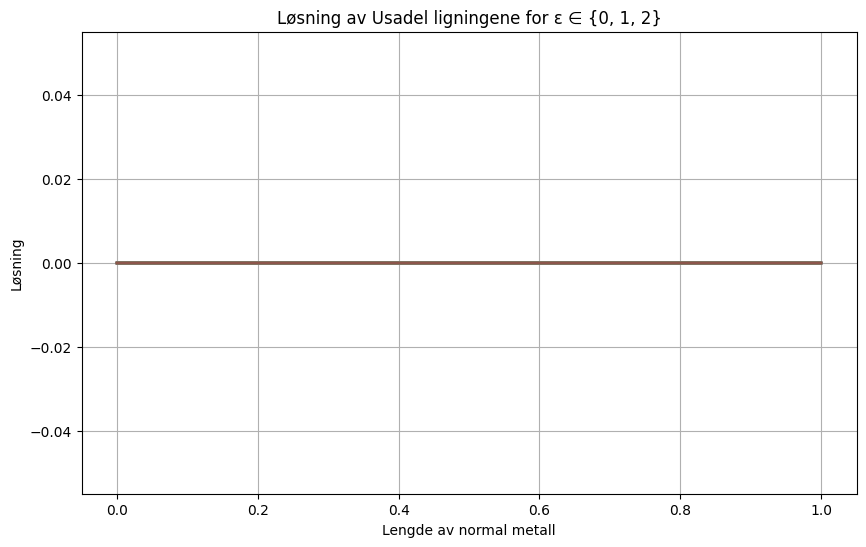

Alle elementene i y er null


In [ ]:
# Setter opp startbetingelser
l = 1
m = 101
x = np.linspace(0, l, m)
y = np.zeros((32,m))
epsilons = [0, 1, 2]

# Itererer over forskjellige epsilon verdier, løser og plotter Usadel ligningene
for epsilon in epsilons:
    sol = scipy.integrate.solve_bvp(derivativeForPosition, boundaryConditionsNormal, x, y)
    plt.plot(x, sol.sol(x).T)

plt.ylabel("Løsning")
plt.xlabel("Lengde av normal metall")
plt.title("Løsning av Usadel ligningene for ε ∈ {0, 1, 2}")
plt.grid(True)
plt.show()

# Kontrollere at alle elementene i y er null
assert np.all(y == 0), "Noen elementer i y er ikke null"
print("Alle elementene i y er null")

Her kan man se på plottet at alle deler av løsningen er null, og assert funksjonen forteller oss det samme. Siden det normale metallet er koblet til to andre normale metall, vil hele løsningen være lik null.

## h)

In [ ]:
def densityOfStates(x, vec):
    rho3 = np.block([[np.eye(2), np.zeros((2, 2))],
            [np.zeros((2, 2)), -np.eye(2)]])

    # For at funksjonen skal fungere dersom man sender inn kun en x verdi og vec med dim(32,1)
    if len(x) == 1:
        gamma, gammaTilde, _, _ = four2DMatricesFromvector32(vec)
        I = np.eye(2)
        N = np.linalg.inv(I - (gamma @ gammaTilde))
        NTilde = np.linalg.inv(I - (gammaTilde @ gamma))
        g = np.block([[(2*N - I), (2*N @ gamma)],
        [(-2*NTilde @ gammaTilde), (-2*NTilde + I)]])
        
        dos = (np.real(np.trace(rho3 @ g))/4)
    
    else:
        dos = []
        for i in range(len(x)):
            gamma, gammaTilde, _, _ = four2DMatricesFromvector32(vec[:,i])
            I = np.eye(2)
            N = np.linalg.inv(I - (gamma @ gammaTilde))
            NTilde = np.linalg.inv(I - (gammaTilde @ gamma))
            g = np.block([[(2*N - I), (2*N @ gamma)],
            [(-2*NTilde @ gammaTilde), (-2*NTilde + I)]])

            dos.append(np.real(np.trace(rho3 @ g))/4)
     
    return dos

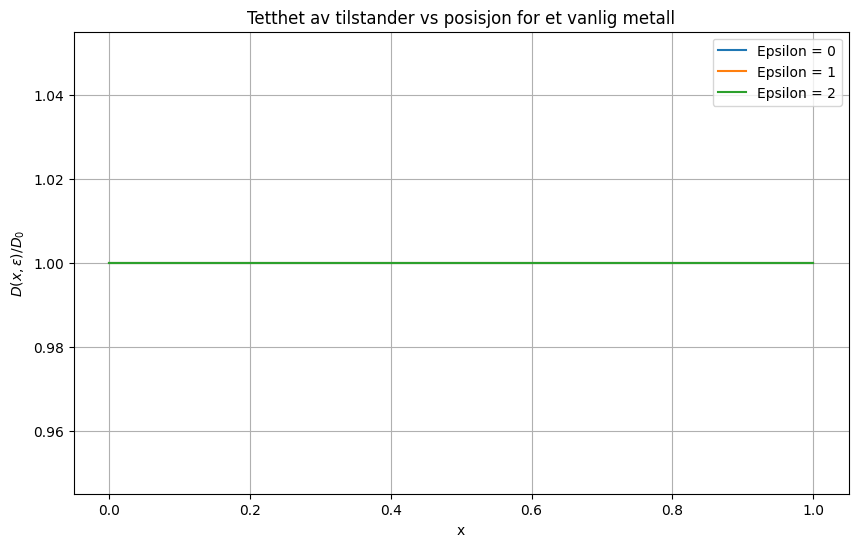

In [ ]:
# Setter opp startbetingelser
l = 1
m = 101
x = np.linspace(0, l, m)
y = np.zeros((32,m))
epsilons = [0, 1, 2]

# Itererer over forskjellige epsilons, løser Usadel ligningene og plotter tettheten av tilstander for løsningen
for epsilon in epsilons:
    sol = scipy.integrate.solve_bvp(derivativeForPosition, boundaryConditionsNormal, x, y)
    DOS = densityOfStates(x, sol.sol(x))
    plt.plot(x, DOS, label=f"Epsilon = {epsilon}")

plt.ylabel("$D(x,ε)/D_0$")
plt.xlabel("x")
plt.title("Tetthet av tilstander vs posisjon for et vanlig metall")
plt.grid(True)
plt.legend()
plt.show()

Her ser man at tettheten av tilstander ikke endrer seg fra referanse tettheten $D_0$. Dette skjer siden det er et normalt metall koblet med to normale metaller.

## i)

In [ ]:
def boundaryConditionsSuperconductor(vLeft, vRight):
    zeta = 3
    delta = 0.01

    # Definerer s og c for beregning av Ricatti matrisene til superlederne
    s = np.sinh(np.arctanh(1/(epsilon+delta*1j)))
    c = np.cosh(np.arctanh(1/(epsilon + delta*1j)))

    # Regner ut Ricatti matrisene til superlederne
    gammaL = np.block([[0, +s/(1+c)],
                      [-s/(1+c), 0]]) * np.exp(1j*phiL)
    gammaTildeL = np.block([[0, -s/(1+c)],
                      [+s/(1+c), 0]]) * np.exp(-1j*phiL)
    gammaR = np.block([[0, +s/(1+c)],
                      [-s/(1+c), 0]]) * np.exp(1j*phiR)
    gammaTildeR = np.block([[0, -s/(1+c)],
                      [+s/(1+c), 0]]) * np.exp(-1j*phiR)

    # Henter ut Ricatti matrisene fra det normale metallet fra venstre og høyre siden
    gamma0, gammaTilde0, omega0, omegaTilde0 = four2DMatricesFromvector32(vLeft)
    gammaEnd, gammaTildeEnd, omegaEnd, omegaTildeEnd = four2DMatricesFromvector32(vRight)

    # Definerer nødvendige matriser
    I = np.eye(2)
    NLeft = np.linalg.inv(I - (gammaL @ gammaTildeL))
    NLeftTilde = np.linalg.inv(I - (gammaTildeL @ gammaL))
    NRight = np.linalg.inv(I - (gammaR @ gammaTildeR))
    NRightTilde = np.linalg.inv(I - (gammaTildeR @ gammaR))

    # Innfører grensebetingelsene
    bcl1 = omega0 + 1/(zeta*l) * (I - gamma0 @ gammaTildeL) @ NLeft @ (gammaL - gamma0)
    bcl2 = omegaTilde0 + 1/(zeta*l) * (I - gammaTilde0 @ gammaL) @ NLeftTilde @ (gammaTildeL - gammaTilde0)
    bcr1 = omegaEnd - 1/(zeta*l) * (I - gammaEnd @ gammaTildeR) @ NRight @ (gammaR - gammaEnd)
    bcr2 = omegaTildeEnd - 1/(zeta*l) * (I - gammaTildeEnd @ gammaR) @ NRightTilde @ (gammaTildeR - gammaTildeEnd)

    # Legger sammen grensebetingelsene til en vektor
    return vector32FromFour2DMatrices(bcl1, bcl2, bcr1, bcr2)

For å forklare hvordan vi har regnet ut Ricatti matrisene til superlederne:

Siden $sinh(z)$ er en odde funksjon og $cosh(z)$ er en like funksjon, er $tanh(z) = \frac{sinh(z)}{cosh(z)}$ en odde funksjon.  
Da må også $atanh(z)$ være odde. Da vil $sinh(atanh(-z)) = -sinh(atanh(z))$ og $cosh(atanh(-z)) = cosh(atanh(z))$.  
Dette gjør at $s_- = -s_+$ og $c_- = c_+$.

Dette er hvorfor vi har kun definert $s$ og $c$, og ikke $s_-$, $s_+$, $c_-$ og $c_+$.

## j)

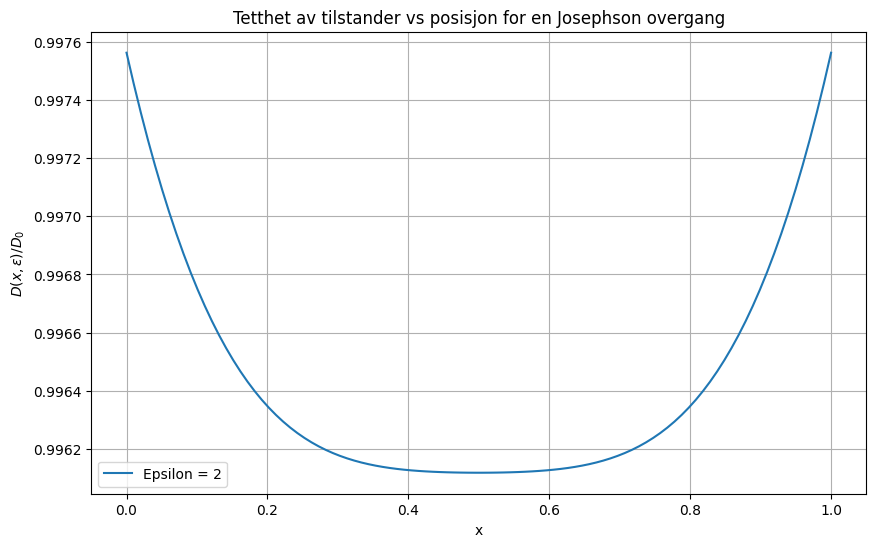

In [ ]:
# Setter opp startbetingelser
l = 1
m = 100
phiL = 0
phiR = 0
x = np.linspace(0, l, m)
y = np.zeros((32,m))
epsilon = 2

# Løser Usadel ligninene for en Josephson overgang og plotter tettheten av tilstander til løsningen
sol = scipy.integrate.solve_bvp(derivativeForPosition, boundaryConditionsSuperconductor, x, y)
DOS = densityOfStates(x, sol.sol(x))
plt.plot(x, DOS, label=f"Epsilon = {epsilon}")
plt.ylabel("$D(x,ε)/D_0$")
plt.xlabel("x")
plt.title("Tetthet av tilstander vs posisjon for en Josephson overgang")
plt.grid(True)
plt.legend()
plt.show()


Når $\epsilon = \frac{E - E_f}{\left|\Delta\right|} = 2$ betyr det at $E - E_f = 2\left|\Delta\right|$. Når energien er så stor, er det så å si ingen superleder egenskaper i superlederne og da heller ikke i metallet. 

Tettheten av tilstander til en superleder ved $\epsilon = 2$ er ca $1.1$, altså litt større enn standard tettheten $D_0$. Det at det er flere tilstander i superlederne gjør at det vil være mer gunstig for elektronene å befinne seg i de "ekstra" tilstandene(til superlederne), og tettheten til den normale metallet vil derfor bli mindre. 

## k)

Integral: 1.0096299834269413
Integral: 1.0027749670486485
Integral: 0.9940905067785699


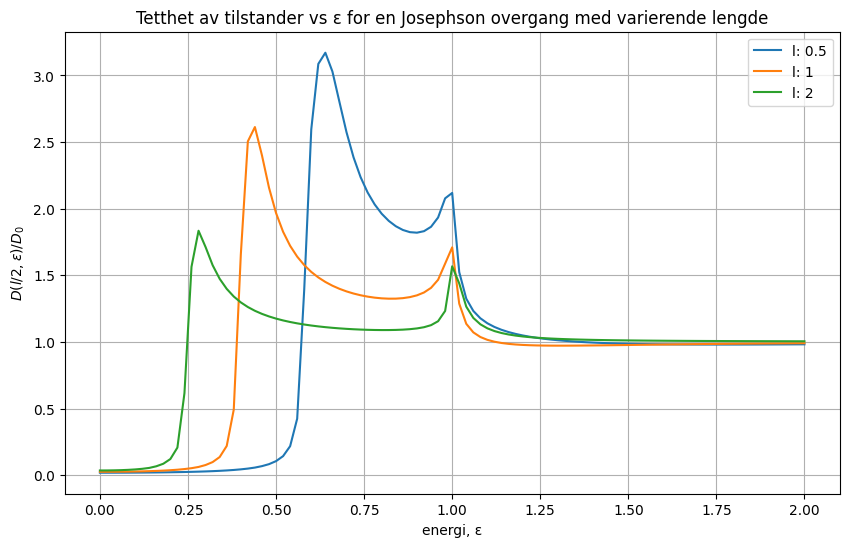

In [ ]:
# Setter opp startbetingelser som ikke endrer seg
ls = [0.5, 1, 2]
m = 100
x = np.linspace(0, l, m)
epsilons = np.linspace(2, 0, 101)

# Kjører koden for l=0.5, 1 og 2
for l in ls:
    # Begynner med en null løsning for epsilon=2
    y = np.zeros((32,m))
    # Itererer for 101 verdier av epsilon mellom 0 og 2
    DOS_values = np.zeros_like(epsilons)
    for j, epsilon in enumerate(epsilons):
        sol = scipy.integrate.solve_bvp(derivativeForPosition, boundaryConditionsSuperconductor, x, y)
        DOS = densityOfStates([l/2], sol.sol(l/2))
        DOS_values[j] = (DOS)
        # Setter initial gjettet, til løsningen for forrige epsilonverdi
        y = sol.sol(x)
        
    # Plotter tettheten av tilstander for x = l/2 og epsilon mellom 0 og 2
    plt.plot(epsilons, DOS_values, label=f"l: {l}")
    # Skriver ut den standeriserte mengden tilstander mellom epsilon = 0 og 2
    print(f"Integral: {-scipy.integrate.simpson(x=epsilons, y=DOS_values)/(abs(epsilons[0] - epsilons[-1]))}")

plt.ylabel("$D(l/2,ε)/D_0$")
plt.xlabel("energi, ε")
plt.title("Tetthet av tilstander vs ε for en Josephson overgang med varierende lengde")
plt.grid(True)
plt.legend()
plt.show()

Her kan du se at minigapet blir "kortere" når lengden av overgangen($l$) blir lengre. Dette skjer fordi superlederevnen må "lekke" igjennom mer materialet, som kun kan skje for mindre energinivå.

Når $l = 0.5$ observerer man at tettheten også blir større (litt over $3D_0$) ved $\epsilon = 0.5$. Etter denne "eksplosive" veksten, reduserer den stabilt fram mot $\epsilon = 1$ hvor en interaksjon i energigrensesnittet $\epsilon = 1$ øker tettheten igjen. Som man ser i figur 1 i oppgave beskrivelsen, har superlederne på $x = 0$ og $x = l$ et stort "hopp" i tettheten når $\epsilon = 1$ og dette vil også "lekke" inn i det normale metallet. Dette er grunnen til det andre "hoppet" i tettheten. 

Ved å sammenligne plottene til tettheten med forskjellige overgangslengde l, ser man at arealet under grafen forblir ca. det samme. Når vi tar integralet av tetthetene med hensyn av epsilon(og deler på $\Delta \epsilon = 2$), blir alle ca. lik 1. Tilstander kan ikke bare forsvinne, så de blir "dyttet" til hvor energien er for høy til at cooper par kan eksistere. 

## l)

In [ ]:
def currentIntegrand(x, vec):
    I = np.eye(2)
    rho3 = np.block([[I, np.zeros((2, 2))],
                     [np.zeros((2, 2)), -I]])

    if len(x) == 1:
        gamma, gammaTilde, omega, omegaTilde = four2DMatricesFromvector32(vec)
        N = np.linalg.inv(I - (gamma @ gammaTilde))
        NTilde = np.linalg.inv(I - (gammaTilde @ gamma))
        g = np.block([[2*N - I, 2*N @ gamma],
                      [-2*NTilde @ gammaTilde, -2*NTilde + I]])
        
        dNdx = N @ (omega @ gammaTilde + gamma @ omegaTilde) @ N
        dNTildedx = NTilde @ (omegaTilde @ gamma + gammaTilde @ omega) @ NTilde
        
        dgdx = 2*np.block([[dNdx, N @ omega + dNdx @ gamma],
                         [-NTilde @ omegaTilde - dNTildedx @gammaTilde, -dNTildedx]])
        
        current = np.real(np.trace(rho3 @ (g @ dgdx - dgdx @ g)))
    else:
        current = []
        for i in range(len(x)):
            gamma, gammaTilde, omega, omegaTilde = four2DMatricesFromvector32(vec[:, i])
            N = np.linalg.inv(I - (gamma @ gammaTilde))
            NTilde = np.linalg.inv(I - (gammaTilde @ gamma))
            g = np.block([[2*N - I, 2*N @ gamma],
                        [-2*NTilde @ gammaTilde, -2*NTilde + I]])
            
            dNdx = N @ (omega @ gammaTilde + gamma @ omegaTilde) @ N
            dNTildedx = NTilde @ (omegaTilde @ gamma + gammaTilde @ omega) @ NTilde
            
            dgdx = 2*np.block([[dNdx, N @ omega + dNdx @ gamma],
                         [-NTilde @ omegaTilde - dNTildedx @ gammaTilde, -dNTildedx]])
            
            current_value = np.real(np.trace(rho3 @ (g @ dgdx - dgdx @ g)))
            current.append(current_value)
    
    return current

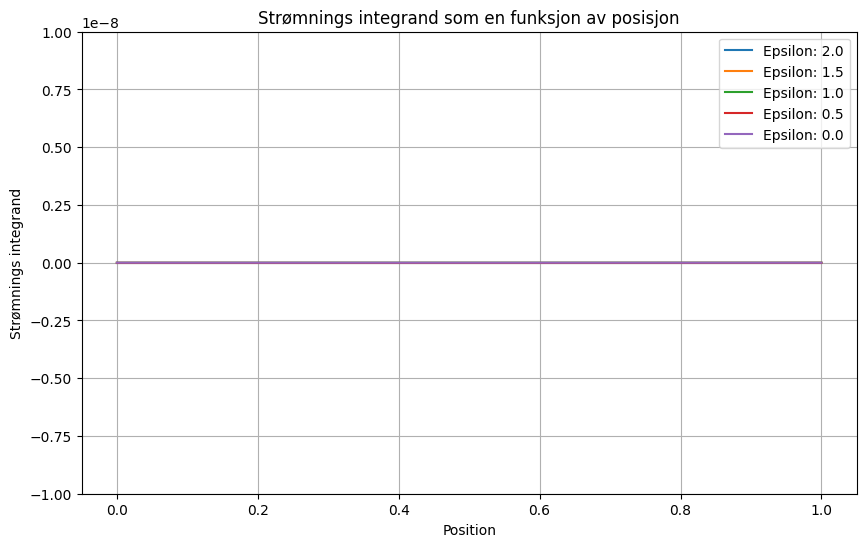

In [ ]:
l = 1
m = 100
phiL = 0
phiR = 0

# Setter start verdier
x = np.linspace(0, l, m)
y = np.zeros((32,m))
epsilons = np.array([2, 1.5, 1, 0.5, 0])
vLeft, vRight = np.zeros(32), np.zeros(32)

currents = []
for epsilon in epsilons:
    sol = scipy.integrate.solve_bvp(derivativeForPosition, boundaryConditionsSuperconductor, x, y)
    currents.append(currentIntegrand(x, sol.sol(x)))
    y = sol.sol(x)

for current, epsilon in zip(currents, epsilons):
    plt.plot(x, current, label=f"Epsilon: {epsilon}")
plt.xlabel('Position')
plt.ylabel('Strømnings integrand')
plt.title('Strømnings integrand som en funksjon av posisjon')
plt.ylim(-10**-8, 10**-8)
plt.legend()
plt.grid(True)
plt.show()

Når $\phi_R = \phi_L = 0$ er det ingen krefter som drar elektron parene i en eller annen retning og det er derfor null "strømtetthet" uansett posisjon. 

## m)

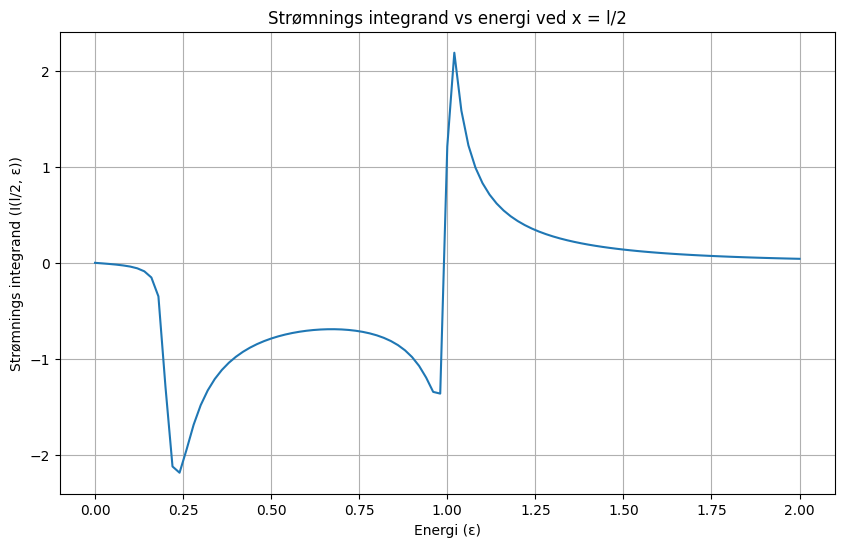

0.5090445706576636


In [ ]:
l = 1
m = 100
phiL = 1
phiR = 0

x = np.linspace(0, l, m)
y = np.zeros((32,m))
epsilons = np.linspace(2, 0, 101)
vLeft, vRight = np.zeros(32), np.zeros(32)

currentIntegrands = []
for epsilon in epsilons:
    sol = scipy.integrate.solve_bvp(derivativeForPosition, boundaryConditionsSuperconductor, x, y)
    currentIntegrands.append(currentIntegrand([l/2], sol.sol(l/2)))
    y = sol.sol(x)

plt.plot(epsilons, currentIntegrands)
plt.xlabel('Energi (ε)')
plt.ylabel('Strømnings integrand (I(l/2, ε))')
plt.title('Strømnings integrand vs energi ved x = l/2')
plt.grid(True)
plt.show()

# Skriver ut integralet av strømnings integranden med hensyn på epsilon
print(scipy.integrate.simpson(x=epsilons, y=currentIntegrands))

Her er $\Delta \phi = 1$ og det er derfor en kraft som drar elektron parene. Dette er hvorfor integranden ikke er null, imotsetning til forrige graf når $\Delta \phi = 0$. Formen til integranden(er ikke viktig) bestemmes av greens funksjonen og dens deriverte, og ligner derfor på tetthetsplottet over (som også er en funksjon av greens funksjonen). Strømningsintegranden er den samme over hele lederen, og derfor konservert, fordi superstrømmen må være kontinuerlig. Dette følger av kontinuitetsligningen for ladning, som sikrer at ingen ladning akkumuleres i en stasjonær tilstand.

## n)

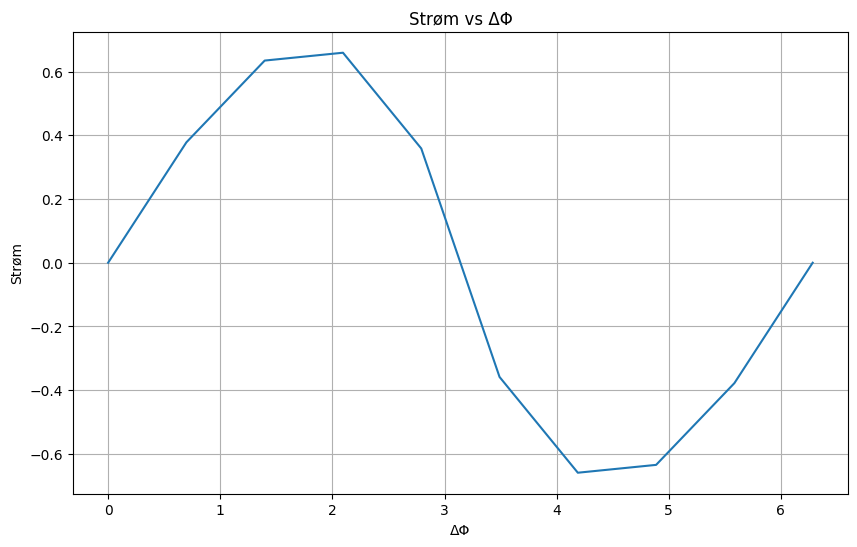

In [ ]:
l = 1
m = 100
phiLs = np.linspace(0, 2*np.pi, 10)
phiR = 0


    

current = []
for phiL in phiLs:
    x = np.linspace(0, l, m)
    y = np.zeros((32,m))
    epsilons = np.linspace(2, 0, 101)
    vLeft, vRight = np.zeros(32), np.zeros(32)

    currentIntegrands = []
    for epsilon in epsilons:
        sol = scipy.integrate.solve_bvp(derivativeForPosition, boundaryConditionsSuperconductor, x, y)
        currentIntegrands.append(currentIntegrand([l/2], sol.sol(l/2)))
        y = sol.sol(x)

    current.append(scipy.integrate.simpson(y=currentIntegrands, x=epsilons))


plt.plot(phiLs, current)
plt.xlabel('ΔΦ')
plt.ylabel('Strøm')
plt.title('Strøm vs ΔΦ')
plt.grid(True)
plt.show()

Her ser man at det er en tydelig superstrøm når $\Delta \phi \not= 0$, hvor retningen og styrken bestemmes av $\Delta \phi$. Man observerer at det er null strøm når $\Delta \phi = 0, \pi $ og $ 2\pi$. Superstrømmen ser ut til å følge en sinusform, som sammensvarer godt med Josephson ligningene. Her kan man se at integralet av integranden i plottet over (som er lik 0.51) samsvarer godt med dette strøm plottet ved $\Delta \phi = 1$

Plottet illustrerer hvordan superstrømmen tydelig avhenger av faseforskjeller mellom superlederne. 
Vi ser at når strømmen er null når superlederne er i fase eller helt ute av fase, hvorimot den er maksimal ved en faseforskjell på $\pi/2$.
 Den sinusoide oppførselen stemmer overens med josephson likningen for strøm i en Josephson junction: $I = I_{c} sin(\Delta \phi)$.